# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals
---
* **Author**: Carmen-Theodora Craciun
* **The purpose of this Notebook**: This notebook handles ...
* **Datasets**: [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) and [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
    * Sleep Cassette (SC) - the study on healthy people;
    * Sleep Telemetry (ST) - sleep study in people with difficulty falling asleep. This study was designed to look at the effects of temazepam, a drug with hypnotic effects;
    * UCDDB - patients diagnosed with apnea, who do not suffer from cardiological diseases or autonomic dysfunctions and are not taking medication at the time of registration.

In [51]:
import warnings
warnings.filterwarnings("ignore")

In [37]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
import joblib

import utils

In [18]:
file_path = './process_dataset/test/hmc034.npz'
tmp_dir = './tmp_for_hypno'
os.makedirs(tmp_dir, exist_ok=True)

for f in os.listdir(tmp_dir):
    os.remove(os.path.join(tmp_dir, f))

shutil.copy(file_path, tmp_dir)

'./tmp_for_hypno/hmc034.npz'

# Helper functions

In [40]:
def plot_hypnogram(y_true, y_pred, model_name, save_path):
    plt.figure(figsize=(18, 5))
    plt.plot(y_true, label="True", linewidth=2)
    plt.plot(y_pred, label="Predicted", alpha=0.7)
    plt.yticks([0,1,2,3,4], ["W","N1","N2","N3","REM"])
    plt.xlabel("Epoch")
    plt.ylabel("Stage")
    plt.title(f"Hypnogram - {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(save_path)

    plt.show()
    plt.close()

def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [132]:
def run_model(model_name, model, mask, X_or_gen, y_true, processing_time, results, save_folder):
    start_time = time.time()
    # -----------------------------
    # Ensemble (y_pred and y_true exist already)
    # -----------------------------
    if model_name in ["LGBM_MLP", "LSTM_ResNet"]:
        start_time = time.time()
        y_pred, y_true = model  # model is a tuple (y_pred, y_true)
        y_proba = None  # ensemble do not have proba

        acc = compute_accuracy(y_true, y_pred)
        save_path = f"{save_folder}/hypnogram_{model_name}.png"
        plot_hypnogram(y_true, y_pred, model_name, save_path)
        end_time = time.time()

        total_time = processing_time + end_time - start_time
        print(f"Model {model_name} generated the hypnogram in {total_time:.4f} seconds with an accuracy of {acc:.4f}.")
        results.loc[mask, 'hypno_acc'] = acc
        results.loc[mask, 'gen_time'] = total_time
        results.loc[mask, 'hypno_path'] = save_path
        
        return
        
    # The other models
    if model_name in ["MLP","LSTM","ResNet"]:
        y_proba = model.predict(X_or_gen)
        y_pred = np.argmax(y_proba, axis=1)

    elif model_name in ["CNN", "SSN"]:
        # extract all the real labels from the generator
        all_y = []
        for i in range(len(X_or_gen)):
            _, yb = X_or_gen[i]
            all_y.append(np.argmax(yb, axis=1))
        y_true = np.concatenate(all_y)

        # predictions → probabilities → classes
        y_proba = model.predict(X_or_gen)
        y_pred = np.argmax(y_proba, axis=1)

    else:
        y_proba = model.predict_proba(X_or_gen)
        y_pred = model.predict(X_or_gen)

    acc = compute_accuracy(y_true, y_pred)

    save_path = f"{save_folder}/hypnogram_{model_name}.png"
    plot_hypnogram(y_true, y_pred, model_name, save_path)

    end_time = time.time()
    total_time = processing_time + (end_time - start_time)

    print(f"Model {model_name} generated the hypnogram in {total_time:.4f} seconds with an accuracy of {acc:.4f}.")
    results.loc[mask, 'hypno_acc'] = acc
    results.loc[mask, 'gen_time'] = total_time
    results.loc[mask, 'hypno_path'] = save_path

    return y_proba

# Getting the results file

In [103]:
results = pd.read_csv("./model_results.csv")

results['hypno_acc'] = None
results['gen_time'] = None
results['hypno_path']=None

# Process Dataset

## Feature extraction

Note: Used the script file `feature_extraction_pipeline` that contains the functions and logic with the Notebook Feature Extraction, but only for one file.

In [104]:
from feature_extraction_pipeline import process_single_npz
import time

start_time = time.time()
df = process_single_npz(file_path)
feature_cols = [c for c in df.columns if c not in ['Subject_ID', 'Dataset_Source', 'Label']]
X = df[feature_cols]
y = df['Label']
end_time = time.time()

feature_extr_time = end_time - start_time
print(f"File process for LGBM, XGB, RF and MLP. Time: {feature_extr_time}")

File process for LGBM, XGB, RF and MLP. Time: 8.040000200271606


## Build sequences (for LSTM and ResNet)

In [105]:
start_time = time.time()
df['Subject_ID'] = 1
X_seq, y_seq, _ = utils.build_sequences_per_subject(df, feature_cols, seq_len=30, step=5)
end_time = time.time()

feature_extr_seq_time = feature_extr_time + end_time - start_time
print(f"File process for LSTM and ResNet. Time: {feature_extr_seq_time}")

File process for LSTM and ResNet. Time: 8.051526546478271


## The generator for CNN

In [106]:
start_time = time.time()

test_gen_cnn = utils.SleepDataGenerator(
    tmp_dir,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)
end_time = time.time()
cnn_gen_time = end_time - start_time
print(f"File process for CNN. Time: {cnn_gen_time}")

File process for CNN. Time: 0.00027632713317871094


## The generator for SeqSleepNet

In [107]:
start_time = time.time()

test_gen_ssn = utils.SleepDataGenerator(
    tmp_dir,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=False,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5,
    select_channels=[0] 
)
end_time = time.time()
ssn_gen_time = end_time - start_time
print(f"File process for SeqSleepNet. Time: {ssn_gen_time}")

File process for SeqSleepNet. Time: 0.00025153160095214844


# Models

## LightGBM

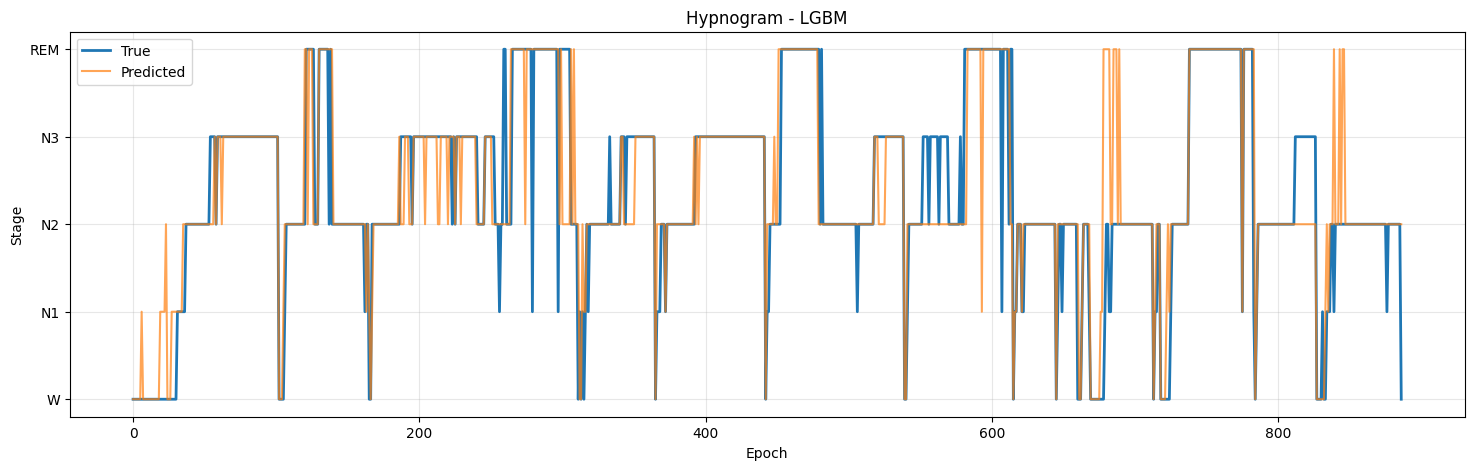

Model LGBM generated the hypnogram in 8.6391 seconds with an accuracy of 0.8162.


In [129]:
model_name = 'LGBM'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

y_proba_lgbm = run_model(
    model_name=model_name,
    X_or_gen=X,
    y_true=y,
    mask = mask,
    model = model,
    processing_time = feature_extr_time,
    results=results,
    save_folder="./results"
)

## XGBoost

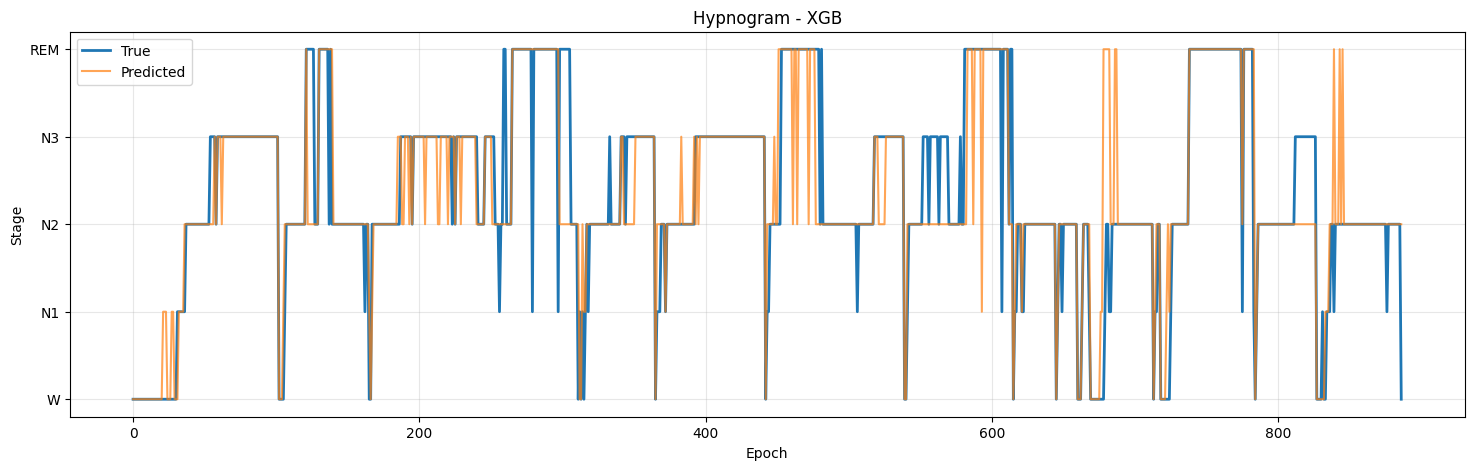

Model XGB generated the hypnogram in 8.7217 seconds with an accuracy of 0.8230.


In [110]:
model_name = 'XGB'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_model(
    model_name=model_name,
    X_or_gen=X,
    y_true=y,
    mask = mask,
    model = model,
    processing_time = feature_extr_time,
    results=results,
    save_folder="./results"
)

## Random Forest

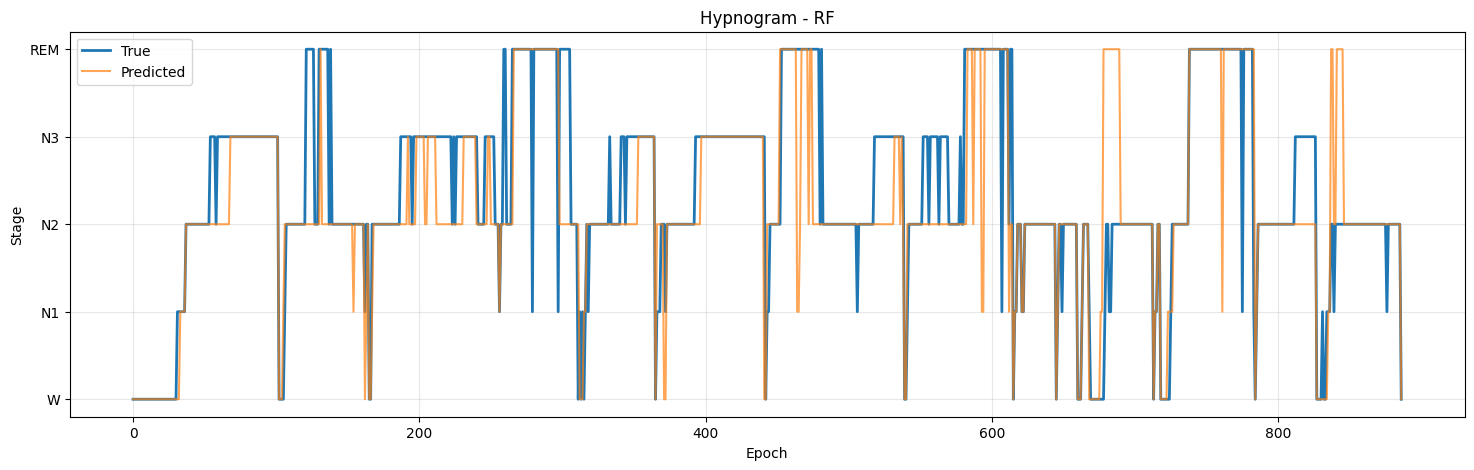

Model RF generated the hypnogram in 8.8689 seconds with an accuracy of 0.7599.


In [111]:
model_name = 'RF'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_model(
    model_name=model_name,
    X_or_gen=X,
    y_true=y,
    mask = mask,
    model = model,
    processing_time = feature_extr_time,
    results=results,
    save_folder="./results"
)

## LDA

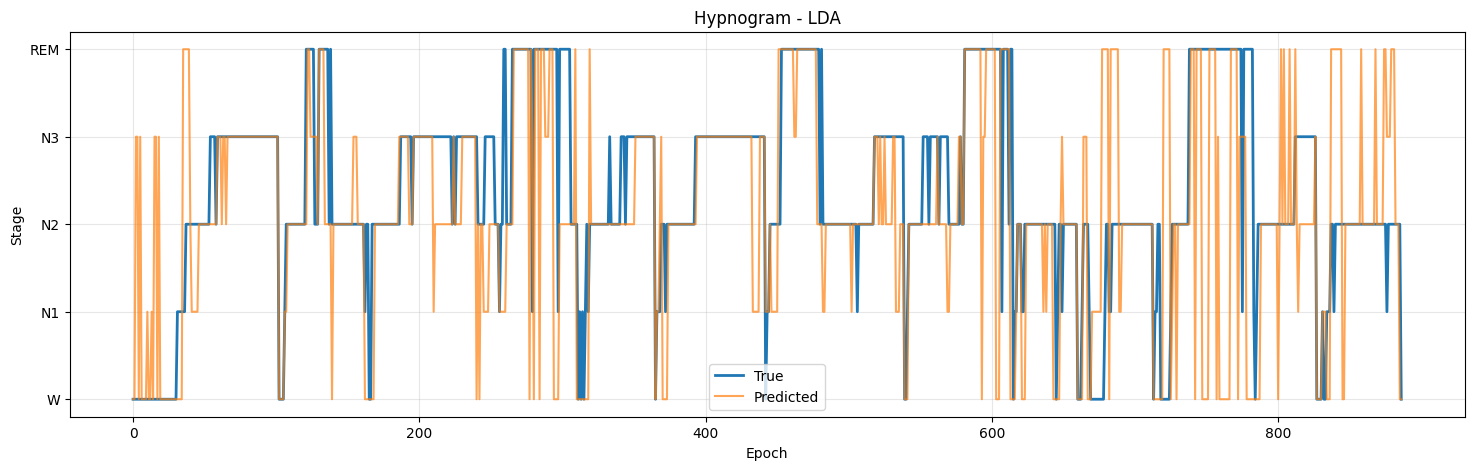

Model LDA generated the hypnogram in 8.4856 seconds with an accuracy of 0.6426.


In [112]:
model_name = 'LDA'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_model(
    model_name=model_name,
    X_or_gen=X,
    y_true=y,
    mask = mask,
    model = model,
    processing_time = feature_extr_time,
    results=results,
    save_folder="./results"
)

## Logistic Regression

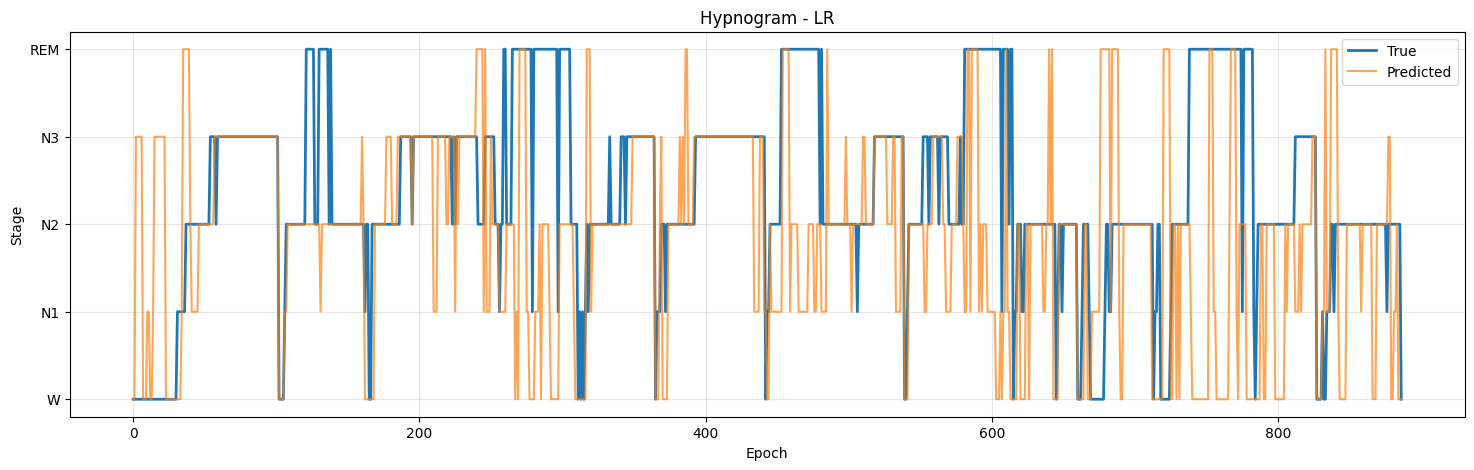

Model LR generated the hypnogram in 8.4645 seconds with an accuracy of 0.5569.


In [113]:
model_name = 'LR'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_model(
    model_name=model_name,
    X_or_gen=X,
    y_true=y,
    mask = mask,
    model = model,
    processing_time = feature_extr_time,
    results=results,
    save_folder="./results"
)

## MLP

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


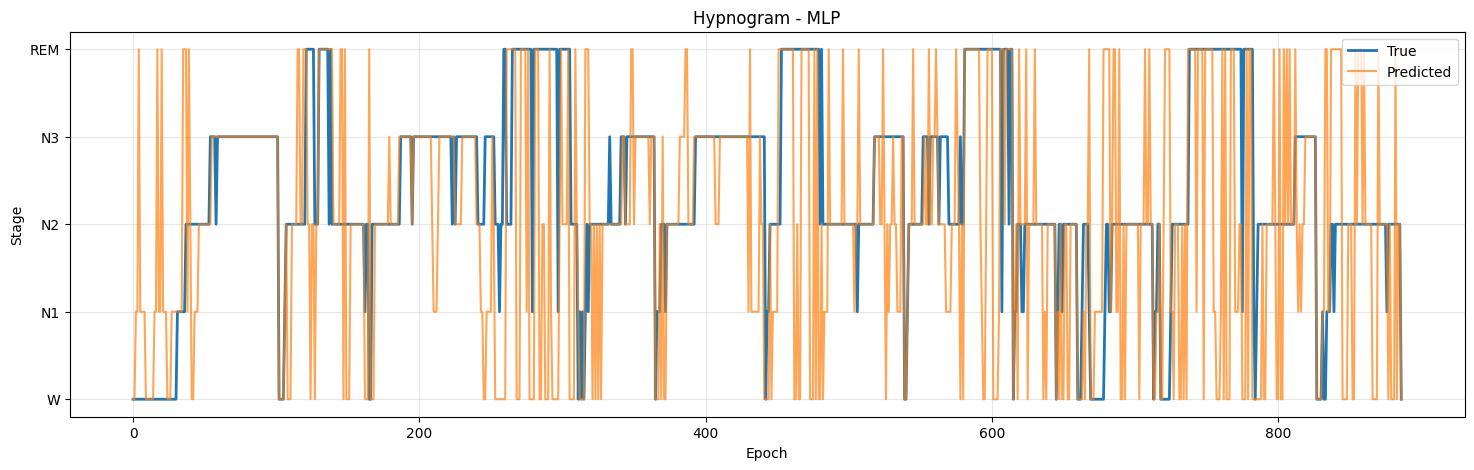

Model MLP generated the hypnogram in 8.8841 seconds with an accuracy of 0.5671.


In [114]:
model_name = 'MLP'
mask = (results['name'] == model_name)
model = load_model(results.loc[mask,'path'].values[0])

y_proba_mlp = run_model(
    model_name=model_name,
    X_or_gen=X,
    y_true=y,
    mask = mask,
    model = model,
    processing_time = feature_extr_time,
    results=results,
    save_folder="./results"
)

## LSTM

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step


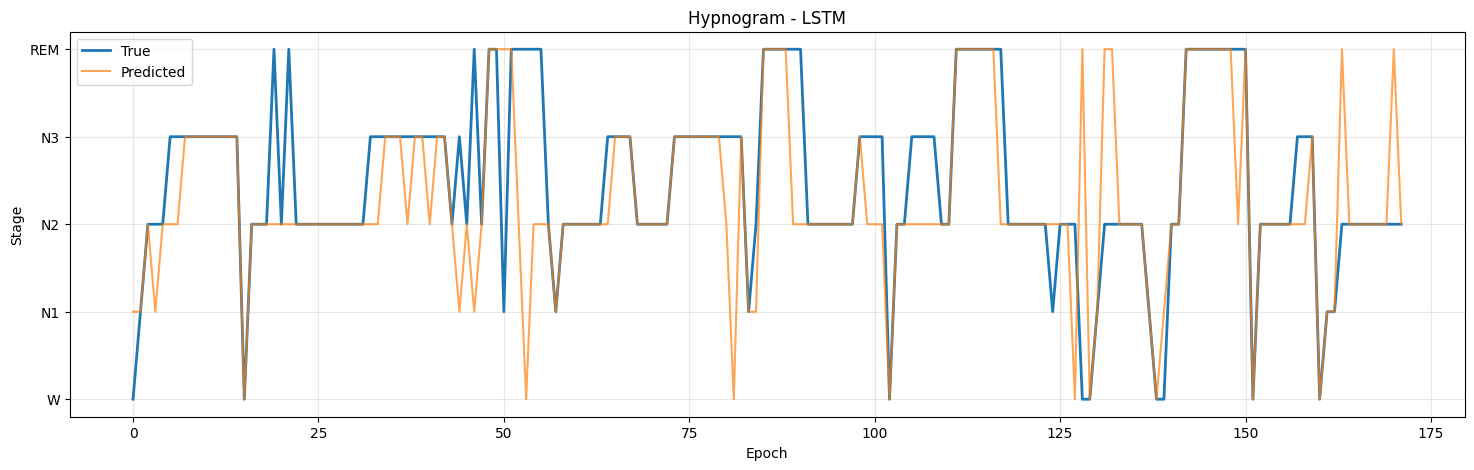

Model LSTM generated the hypnogram in 10.4078 seconds with an accuracy of 0.7558.


In [115]:
model_name = 'LSTM'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0],
    custom_objects={
        "se_feature_attention": utils.se_feature_attention,
        "focal_loss": utils.categorical_focal_loss
    },
    compile=False
)

y_proba_lstm = run_model(
    model_name=model_name,
    X_or_gen=X_seq,
    y_true=y_seq,
    mask = mask,
    model = model,
    processing_time = feature_extr_seq_time,
    results=results,
    save_folder="./results"
)

## ResNet

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


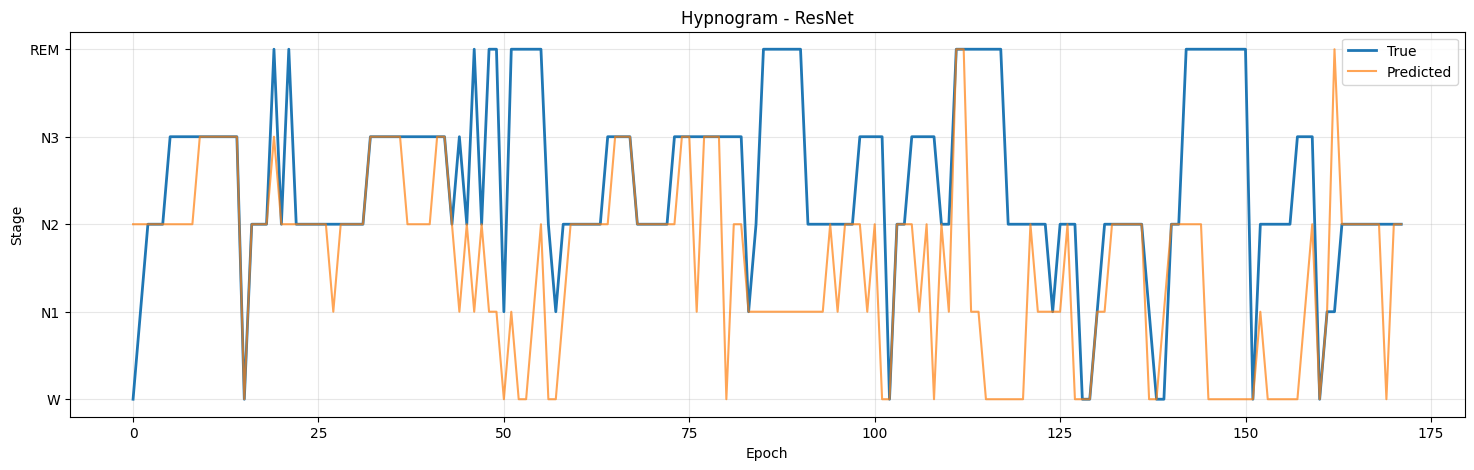

Model ResNet generated the hypnogram in 9.0816 seconds with an accuracy of 0.5000.


In [116]:
model_name = 'ResNet'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0],
    compile=False
)

y_proba_resnet = run_model(
    model_name=model_name,
    X_or_gen=X_seq,
    y_true=y_seq,
    mask = mask,
    model = model,
    processing_time = feature_extr_seq_time,
    results=results,
    save_folder="./results"
)

## CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


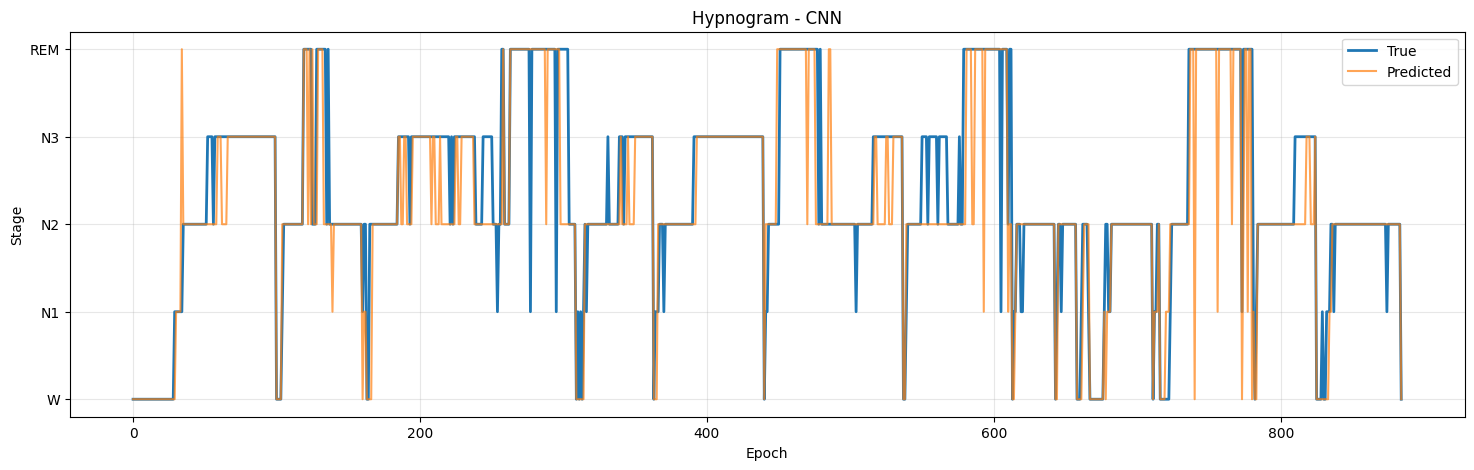

Model CNN generated the hypnogram in 4.2200 seconds with an accuracy of 0.8056.


In [117]:
model_name = 'CNN'
mask = (results['name'] == model_name)
model = load_model(results.loc[mask,'path'].values[0], compile=False)

_ = run_model(
    model_name=model_name,
    X_or_gen=test_gen_cnn,
    y_true=None,
    mask = mask,
    model = model,
    processing_time = cnn_gen_time,
    results=results,
    save_folder="./results"
)

## SeqSleepNet

1/1 ━━━━━━━━━━━━━━━━━━━━ 96s 96s/step


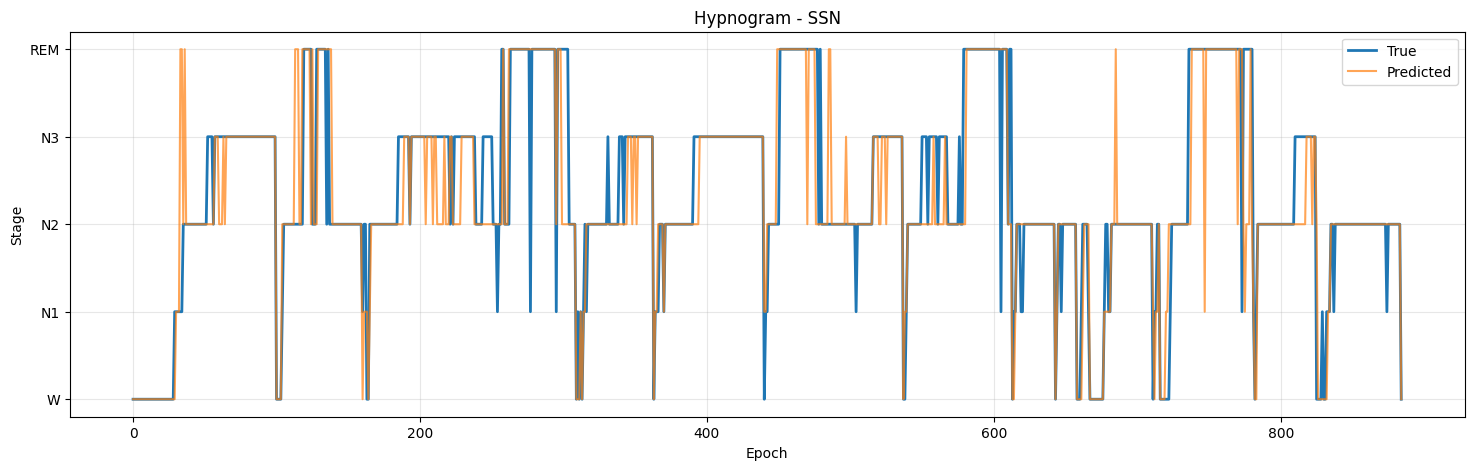

Model SSN generated the hypnogram in 98.1064 seconds with an accuracy of 0.8181.


In [122]:
model_name = 'SSN'
mask = (results['name'] == model_name)
custom_objects = {
    "Attention": utils.Attention,
    "se_feature_attention": utils.se_feature_attention,
    "categorical_focal_loss": utils.categorical_focal_loss(),
    "loss": utils.categorical_focal_loss(),
}

model = load_model(
    results.loc[mask, 'path'].values[0],
    custom_objects=custom_objects,
    compile=False
)

_ = run_model(
    model_name=model_name,
    X_or_gen=test_gen_ssn,
    y_true=None,
    mask = mask,
    model = model,
    processing_time = ssn_gen_time,
    results=results,
    save_folder="./results"
)

## LSTM & ResNet

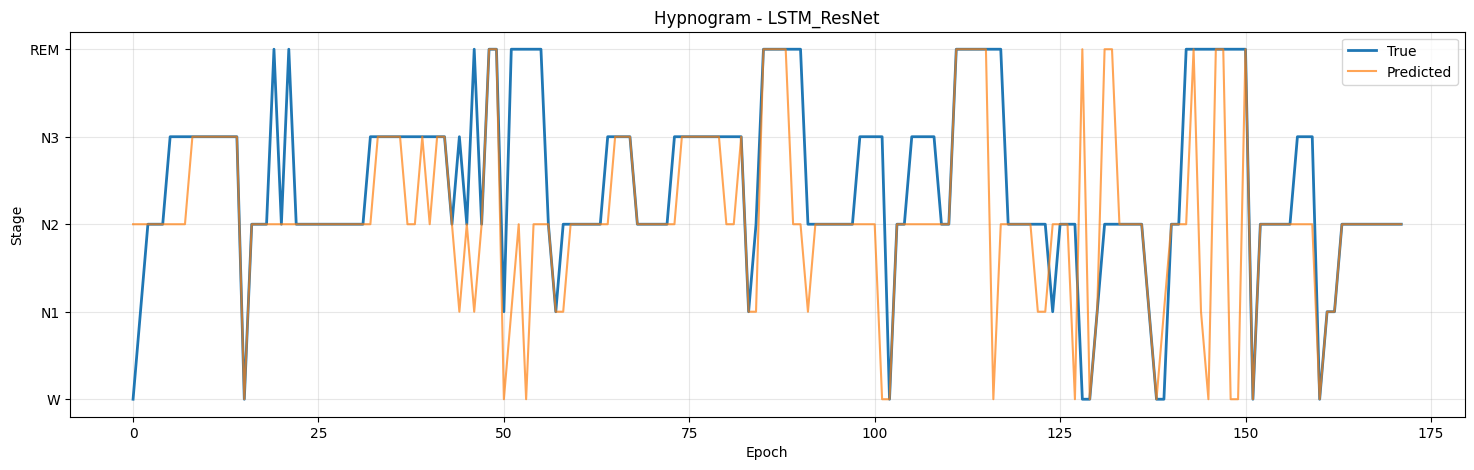

Model LSTM_ResNet generated the hypnogram in 0.3868 seconds with an accuracy of 0.6860.


In [ ]:
y_proba_ens = 0.65 * y_proba_lstm + (1 - 0.65) * y_proba_resnet
y_pred_ens = y_proba_ens.argmax(axis=1)
processing_time = results.loc[results['name'].isin(['LSTM','ResNet']), 'gen_time'].sum()

_ = run_model(
    model_name="LSTM_ResNet",
    model=(y_pred_ens, y_seq),
    mask=(results['name'] == "LSTM_ResNet"),
    X_or_gen=None,
    y_true=None,
    processing_time=0,
    results=results,
    save_folder="./results"
)

# Save data

In [139]:
results.to_csv("./model_results.csv", index=False)

import shutil
shutil.make_archive("best_models", "zip", "best_models")
shutil.make_archive("results", "zip", "results")

'/home/ubuntu/results.zip'